For my project, I will try to combine a CNN and an RNN model like in the paper described in my projet proposal, as the model described was very accurate. 
Combining these two types of neural network will enable me to exploit their respective strengths: CNNs are effective at extracting local patterns, while RNNs capture sequential order and contextual information. I will use the architecture from the paper, with some simplifications, to make the implementation easier and better suited to my level. A diagram of the architecture is in 1.

First the dataset is cleaned and tokenized. Then padding is added (since the CNN can only process inputs of the same lenght) and an embedding layer is added to focus on politically meaningful words. The data are then run through four neural networks in parallel: three CNNs with different filter sizes (2, 3 and 4) to detect bigrams, trigrams and quadrigrams, and an LSTM to process word order. The outputs of CNNs and LSTM layers are then run through a max pooling function to focus on the most important features detected. The outputs of CNNs and LSTM layers are then concatenated into a vector, which passes through two fully connected layers for feature refinement and a dropout layer to prevent overfitting. Finally, a softmax layer computes the final probabilities for each political party.

## Data loading, spliting, and tokenazing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load and split the Data

df = pd.read_parquet('congress_tweets_dataset_cleaned.parquet')

# We use 75% for training, 10% for validation and 15% for testing and take the most recents tweets for testing

#Ensure the time column is in datetime format
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

train_ratio = 0.75
validation_ratio = 0.85

# Split each party's data chronologically
# This ensures that for BOTH 'D' and 'R', the last 25% are used for testing (so we keep the same proportion of republicain and democrat tweets in both sets)

test_list = []
temp_train_val_list = []  #I don't want the validation set to have more recent tweets than the training set

for label in ['D', 'R']:
    party_df = df[df['label'] == label]
    
    # Calculate the split point (index)
    split_idx = int(len(party_df) * validation_ratio)
    
    # Split: first 85% to train+validation, last 15% to test
    temp_train_val_list.append(party_df.iloc[:split_idx])
    test_list.append(party_df.iloc[split_idx:])

# Combine the splits back into final DataFrames
df_train_val = pd.concat(temp_train_val_list)
df_test = pd.concat(test_list)

# Shuffle the training and test/val data (because I want the most recent tweets for testing but I want validation and training to be randomly sampled from the rest of the data)
df_train_val = df_train_val.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

#creating the validation and train set and making sure to keep the same R/D ratio in both sets
train_list = []
validation_list = []

for label in ['D', 'R']:
    party_df = df_train_val[df_train_val['label'] == label]
    
    # Calculate the split point (index)
    split_idx = int(len(party_df) * (train_ratio/validation_ratio))
    
    # Split: 75/85% of train and 10/85% of validation
    train_list.append(party_df.iloc[:split_idx])
    validation_list.append(party_df.iloc[split_idx:])

# Combine the splits back into final DataFrames
df_train = pd.concat(train_list)
df_validation = pd.concat(validation_list)

# We split the features and the labels 
X_train, y_train = df_train['text'], df_train['label']
X_val, y_val = df_validation['text'], df_validation['label']
X_test, y_test = df_test['text'], df_test['label']

# Verification
print(f"Training set size: {len(X_train)} (Ending at {df_train['time'].max()})")
print(f"Validation set size: {len(X_val)} (Ending at {df_validation['time'].max()})")
print(f"Test set size: {len(X_test)} (Starting from {df_test['time'].min()})")
print(f"\nLabel distribution in Test set:\n{y_test.value_counts(normalize=True)}")

Training set size: 3264205 (Ending at 2022-07-28 05:52:12+00:00)
Validation set size: 435228 (Ending at 2022-07-28 04:58:45+00:00)
Test set size: 652842 (Starting from 2022-05-24 15:20:42+00:00)

Label distribution in Test set:
label
D    0.589824
R    0.410176
Name: proportion, dtype: float64


Preparation of the data (tokenization and creation of dataloaders)

In [3]:
import torch
from collections import Counter
import numpy as np


label_map = {'R': 0, 'D': 1}
y_train_num = y_train.map(label_map).values
y_val_num = y_val.map(label_map).values
y_test_num = y_test.map(label_map).values

# Tokenization
#We keep capital letters and punctuation

def tokenize(text):
    return str(text).split()

#construction of a vocabulary dictionary mapping each word to a unique index.
word_counts = Counter()
for text in X_train:
    word_counts.update(tokenize(text))

#to reduce noise, we ignore words that appear less than 5 times in the training set and we add special tokens for padding and unknown words.
min_freq = 10
vocab = {'<PAD>': 0, '<UNK>': 1}

for word, count in word_counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)

print(f"Vocabulary size : {len(vocab)} words.")


Vocabulary size : 203905 words.


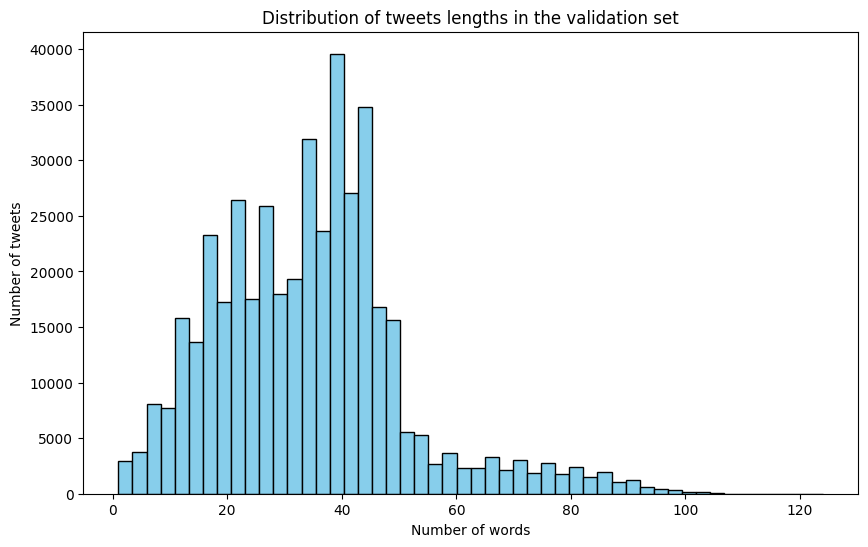

In [4]:
lengths = [len(tokenize(tweet)) for tweet in X_val]

df_lengths = pd.Series(lengths)

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of tweets lengths in the validation set')
plt.xlabel('Number of words')
plt.ylabel('Number of tweets')
plt.show()

In [5]:
# Padding and text encoding

MAX_LEN = 100 #fixed lenght for the tweets, determined using the distribution of tweet lengths in the validation set, that allows to keep most of the tweets without too much noise and reduce the computational cost of the model

def encode_text(text):
    tokens = tokenize(text)
    #we replace each word by its index or by the index of <UNK> if it is unknown
    encoded = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    
    #if the encoded tweet is shorter than MAX_LEN, we pad it with the index <PAD> until it reaches the correct lenght, otherwise we truncate it to MAX_LEN
    if len(encoded) < MAX_LEN:
        encoded += [vocab['<PAD>']] * (MAX_LEN - len(encoded))
    else:
        encoded = encoded[:MAX_LEN]
        
    return encoded

In [6]:
#the training dataset (after tokenization) is too big to be directly converted in a tensor so we have to use a class

from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.values 
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        #we only encode the text of the tweet that we want to use, so we don't have to encode the whole dataset at once and we can use it with a DataLoader that will create batches for us
        encoded = encode_text(text)
        
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_dataset = TweetDataset(X_train, y_train_num)
val_dataset = TweetDataset(X_val, y_val_num)
test_dataset = TweetDataset(X_test, y_test_num)


## Model Building

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class PoliticalClassifier(nn.Module):
    """Main model, largelly inspired by the paper described in the proposal"""
    def __init__(self, name, vocab_size =len(vocab), embedding_dim=128, hidden_dim=128 , dropout_prob=0.5):
        super(PoliticalClassifier, self).__init__()
        self.name = name
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #to avoid empedding the padding filler

        #CNN Branches
        self.conv2 = nn.Conv1d(embedding_dim, 100, kernel_size=2)
        self.conv3 = nn.Conv1d(embedding_dim, 100, kernel_size=3)
        self.conv4 = nn.Conv1d(embedding_dim, 100, kernel_size=4)

        #LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        # global max pooling 1d like in the article
        self.pool = nn.AdaptiveMaxPool1d(1)

        # Fully connected layers for classification
        combined_dim = 300 + hidden_dim
        self.fc1 = nn.Linear(combined_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc_out = nn.Linear(32, 2)

    def forward(self, text):
        embedded = self.embedding(text) # [batch, seq_len, emb_dim]

        # LSTM + Pooling
        lstm_out, _ = self.lstm(embedded)
        # On permute pour le pooling: [batch, hidden_dim, seq_len]
        lstm_feature = self.pool(lstm_out.permute(0, 2, 1)).squeeze(2)

        #  CNN + Pooling
        embedded_cnn = embedded.permute(0, 2, 1)
        x2 = self.pool(F.relu(self.conv2(embedded_cnn))).squeeze(2)
        x3 = self.pool(F.relu(self.conv3(embedded_cnn))).squeeze(2)
        x4 = self.pool(F.relu(self.conv4(embedded_cnn))).squeeze(2)

        # Concatenation
        combined = torch.cat((x2, x3, x4, lstm_feature), dim=1)

        # Dense Layers
        x = F.relu(self.fc1(combined))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))

        # Output
        logits = self.fc_out(x)
        return logits

In [8]:
def get_model_name(name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch):
    path = "model_{0}_bs{1}_lr{2}_hidden{3}_embedding{4}_dropout{5}_epoch{6}".format(name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch)
    return path


def get_accuracy(model, train=False):
    model.eval() #in order not to have dropout 
    if train:
        data = train_dataset
    else:
        data = val_dataset

    correct = 0
    total = 0
    with torch.no_grad():
        for text, labels in torch.utils.data.DataLoader(data, batch_size=20):
            #############################################
            # To Enable GPU Usage
            if torch.cuda.is_available():
                text = text.cuda()
                labels = labels.cuda()
            #############################################
            output = model(text)
            #select index with maximum prediction score
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += text.shape[0]
    return correct / total

In [9]:
def train(model, data, batch_size=20, learning_rate=0.01, hidden_dim=128, embedding_dim=128, dropout_prob=0.5, num_epochs=10,print_stat=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size,shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    iters, losses, train_acc, val_acc = [], [], [], []

    # training
    n = 0 # the number of iterations
    for epoch in range(num_epochs):
        model.train() #in order to have dropout during training
        mini_b=0

        for text, labels in iter(train_loader):

            #To Enable GPU Usage
            text, labels = text.to(device), labels.to(device)

            out = model(text)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

          # save the current training information
            iters.append(n)
            losses.append(float(loss.item()))             # compute *average* loss
            n += 1

        train_acc.append(get_accuracy(model, train=True))  # compute training accuracy at the end of the epoch
        val_acc.append(get_accuracy(model, train=False))  # compute validation accuracy

        print ("Epoch %d Finished. " % epoch )

    if print_stat:
      # plotting
      plt.title("Training Curve")
      plt.plot(iters, losses, label="Train")
      plt.xlabel("Iterations")
      plt.ylabel("Loss")
      plt.show()

      plt.title("Training Curve")
      plt.plot(range(num_epochs), train_acc, label="Training")
      plt.plot(range(num_epochs), val_acc, label="Validation")
      plt.xlabel("Iterations")
      plt.ylabel("Validation Accuracy")
      plt.legend(loc='best')
      plt.show()

      print("Final Training Accuracy: {}".format(train_acc[-1]))
      print("Final Validation Accuracy: {}".format(val_acc[-1]))

      # Save the current model (checkpoint) to a file
      model_path = get_model_name(model.name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch)
      torch.save(model.state_dict(), model_path)



## Sanity Checking

In [ ]:
#We check that the model is able to memorize the data on a small dataset

from torch.utils.data import Subset
debug_data = Subset(train_dataset, list(range(42)))
model = PoliticalClassifier("small_model")
train(model, debug_data, print_stat = False)

#obtain accuracy on 42 samples
correct = 0
total = 0
for imgs, labels in torch.utils.data.DataLoader(debug_data, batch_size=42):
    imgs = imgs.cuda()
    labels = labels.cuda()
    output = model(imgs)
    #select index with maximum prediction score
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(labels.view_as(pred)).sum().item()
    total += imgs.shape[0]
print('Accuracy on batch of 42: ', correct / total)